<h1 dir=rtl align=center style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مدل تابعی کراس‌
</font>
</h1>

In [1]:
import keras
print(keras.__version__)

2.15.0


In [2]:
# If you are using a version of Keras lower than 3, you will need to uncomment the following line.
!pip install keras --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 4.8 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 2.15.0
    Uninstalling keras-2.15.0:
      Successfully uninstalled keras-2.15.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.15.0 requires keras<2.16,>=2.15.0, but you have keras 3.0.2 which is incompatible.


In [1]:
import keras
print(keras.__version__)

3.0.2


<h2 dir=rtl align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
بک‌اند کراس
</font>
</h2>

In [2]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

<h2 dir=rtl align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مجموعه‌داده
</font>
</h2>

In [3]:
# Load the data and split it between train and test sets
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


<h3 dir=rtl align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
نرمال‌سازی
</font>
</h3>

In [4]:
# Scale images to the [0, 1] range
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

<h3 dir=rtl align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
تبدیل برچسب
</font>
</h3>

In [5]:
from keras.utils import to_categorical

y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

<h2 dir=rtl align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مدل‌سازی
</font>
</h2>

<h3 dir=rtl align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
شبکه ۱
</font>
</h3>

In [14]:
import keras
from keras import layers

inputs = keras.Input(shape=(28, 28))
x = layers.Flatten()(inputs)
x = layers.Dense(20, activation='relu')(x)
outputs = layers.Dense(10, activation='softmax')(x)
model1 = keras.Model(inputs=inputs, outputs=outputs)

In [15]:
model1.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Layer (type)                       ┃ Output Shape                  ┃     Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)         │ (None, 28, 28)                │           0 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ flatten_3 (Flatten)                │ (None, 784)                   │           0 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ dense_7 (Dense)                    │ (None, 20)                    │      15,700 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ dense_8 (Dense)                    │ (None, 10)                    │         210 │
└────────────────────────────────────┴───────────────────────────────┴─────────────┘

 Total params: 15,910 (62.15 KB)

 Trainable params: 15,910 (62.15 KB)

 Non-trainable params: 0 (0.00 B)

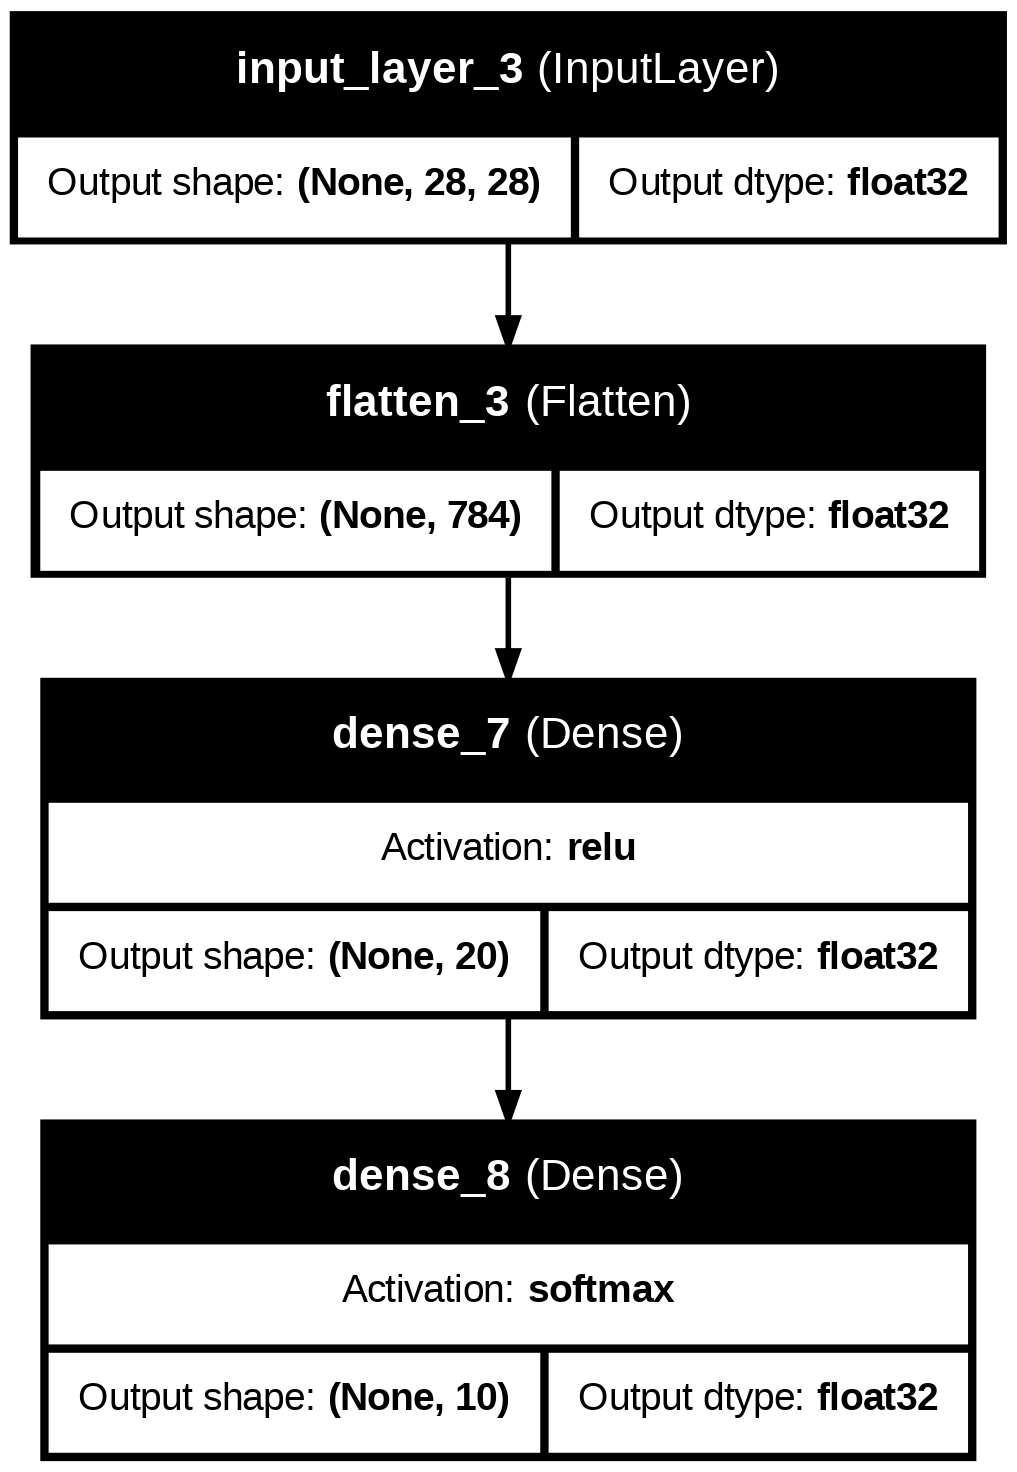

In [16]:
keras.utils.plot_model(model1, to_file='model1.png',
                       show_shapes=True, show_dtype=True,
                       show_layer_activations=True, show_layer_names=True)

<h3 dir=rtl align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
شبکه ۲
</font>
</h3>

In [17]:
import keras
from keras import layers

inputs = keras.Input(shape=(28, 28))
flatten = layers.Flatten()(inputs)
x1 = layers.Dense(20, activation='relu')(flatten)
x2 = layers.Dense(20, activation='relu')(flatten)
x = layers.concatenate([x1, x2])
outputs = layers.Dense(10, activation='softmax')(x)
model2 = keras.Model(inputs=inputs, outputs=outputs)

In [18]:
model2.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃    Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4             │ (None, 28, 28)         │          0 │ -                          │
│ (InputLayer)              │                        │            │                            │
├───────────────────────────┼────────────────────────┼────────────┼────────────────────────────┤
│ flatten_4 (Flatten)       │ (None, 784)            │          0 │ input_layer_4[0][0]        │
├───────────────────────────┼────────────────────────┼────────────┼────────────────────────────┤
│ dense_9 (Dense)           │ (None, 20)             │     15,700 │ flatten_4[0][0]            │
├───────────────────────────┼────────────────────────┼────────────┼────────────────────────────┤
│ dense_10 (Dense)          │ (None, 20)             │     15,700 │ flatten_4[0][0]            │
├───────────────────────────┼────────────────────────┼────────────┼────────────────────────────┤
│ concatenate_1             │ (None, 40)             │          0 │ dense_9[0][0],             │
│ (Concatenate)             │                        │            │ dense_10[0][0]             │
├───────────────────────────┼────────────────────────┼────────────┼────────────────────────────┤
│ dense_11 (Dense)          │ (None, 10)             │        410 │ concatenate_1[0][0]        │
└───────────────────────────┴────────────────────────┴────────────┴────────────────────────────┘

 Total params: 31,810 (124.26 KB)

 Trainable params: 31,810 (124.26 KB)

 Non-trainable params: 0 (0.00 B)

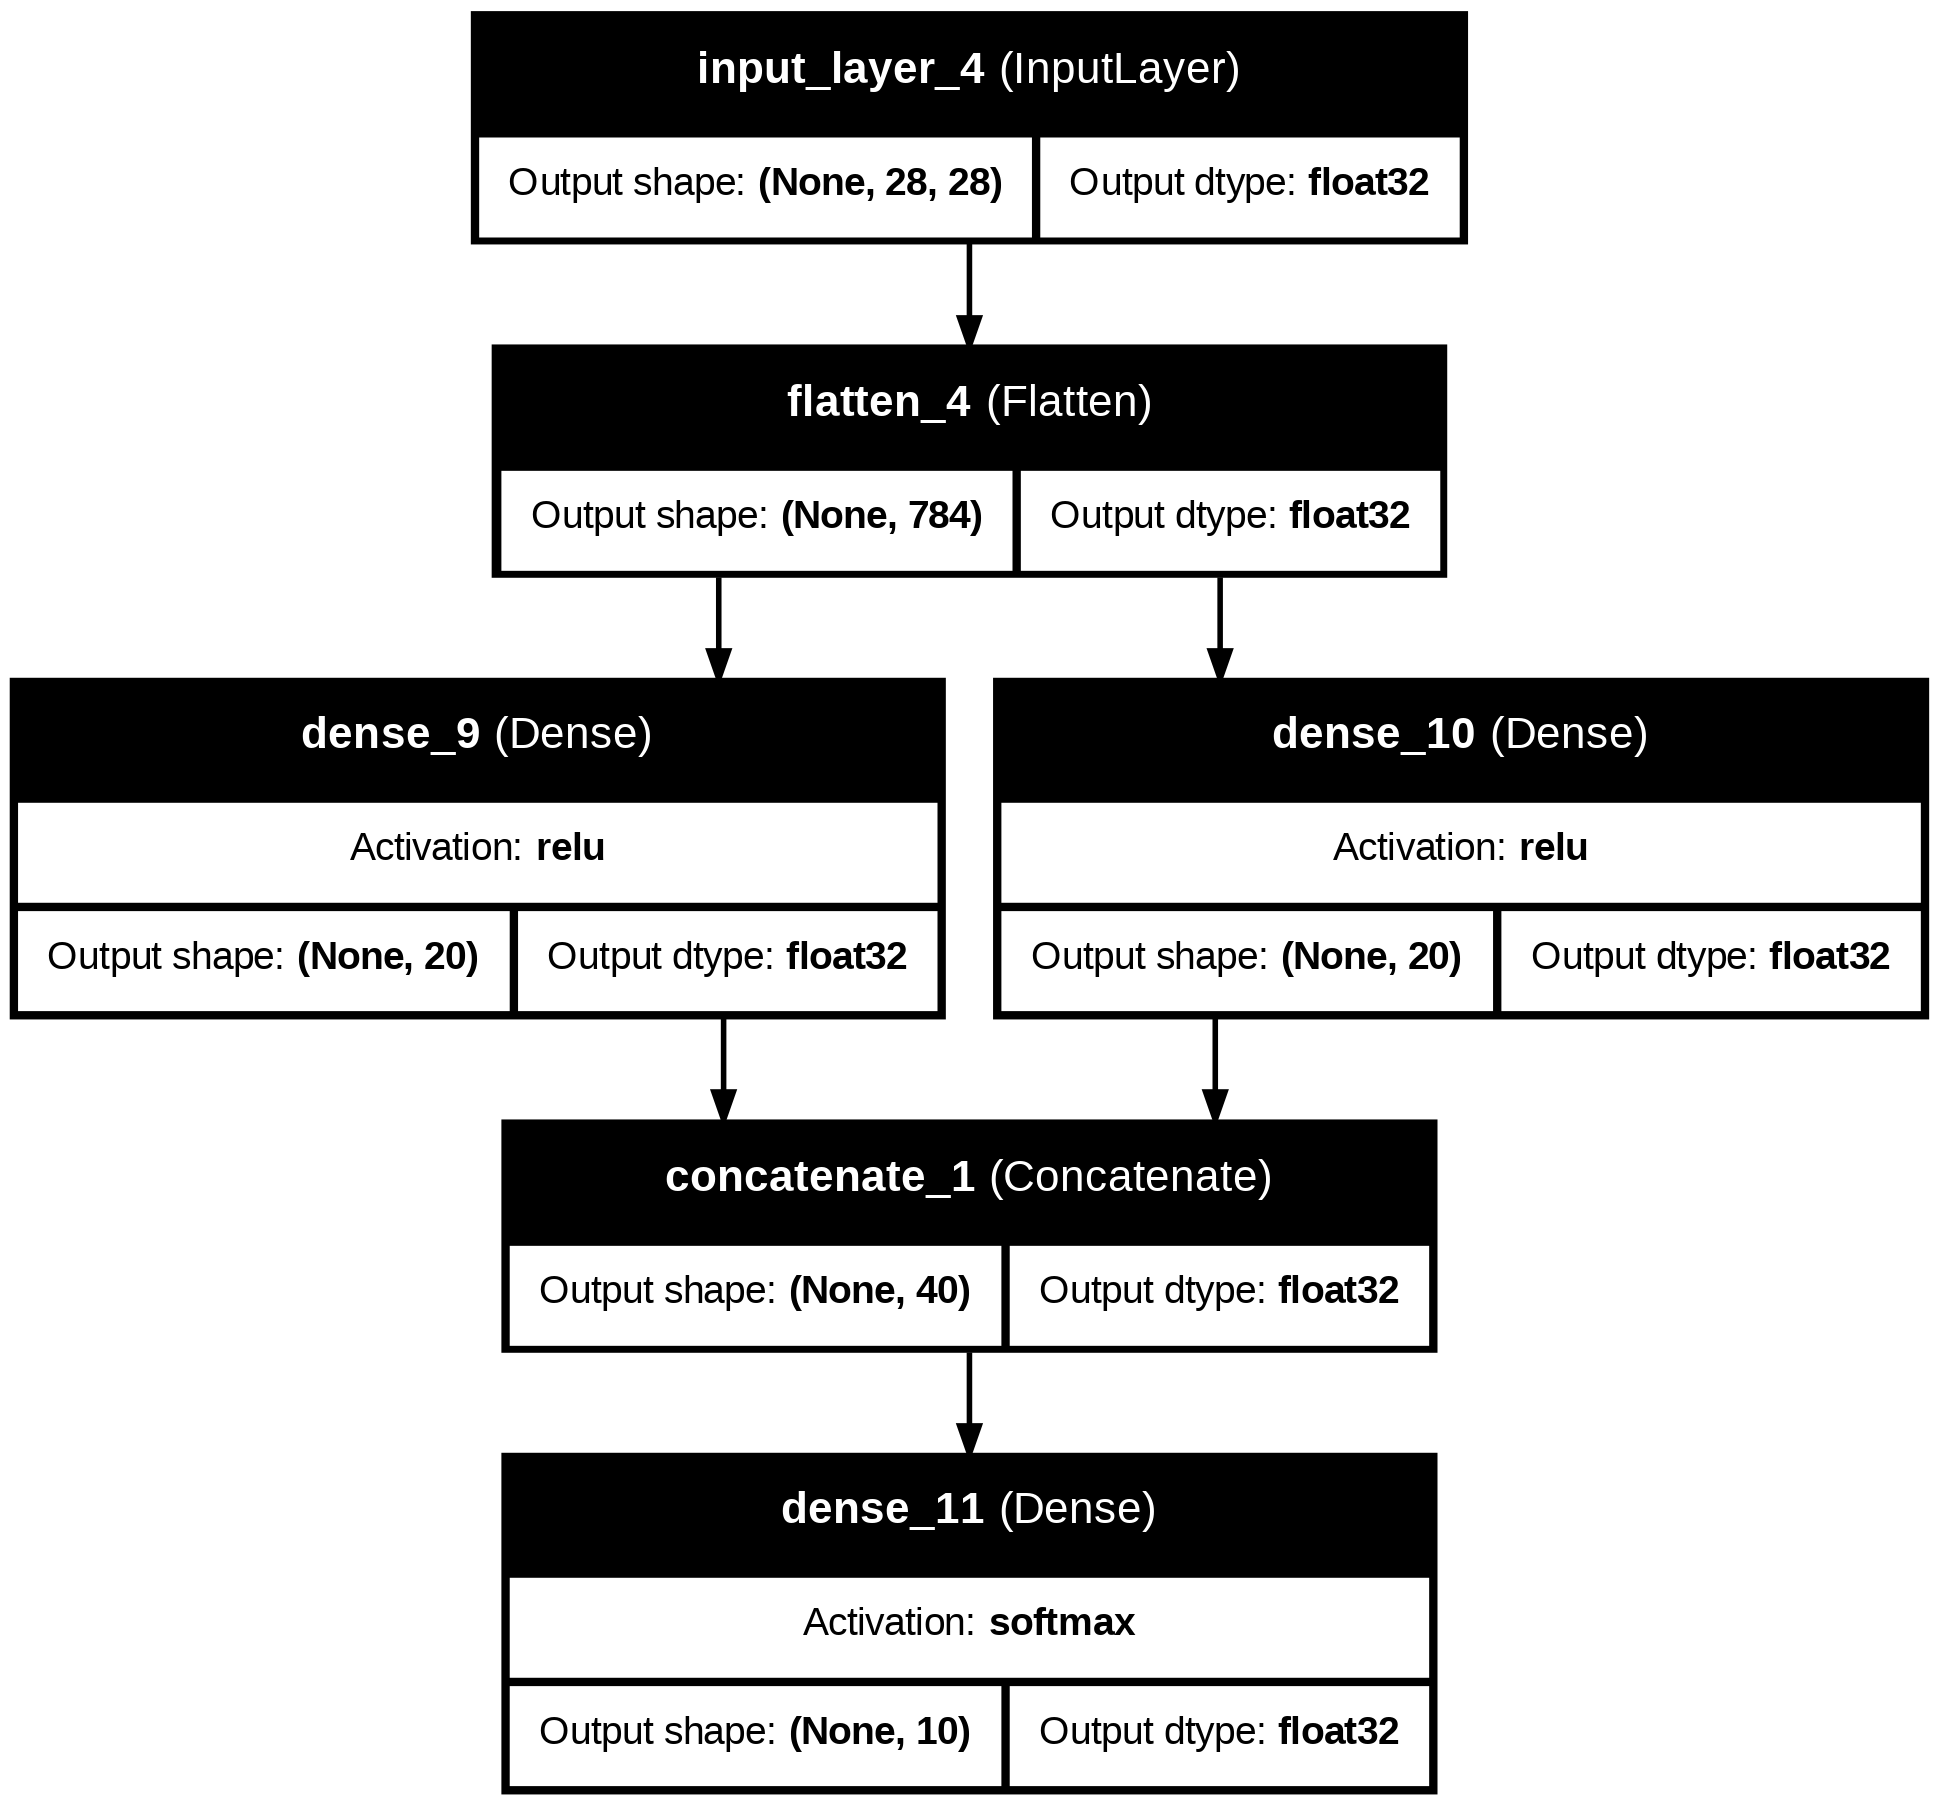

In [19]:
keras.utils.plot_model(model2, to_file='model2.png',
                       show_shapes=True, show_dtype=True,
                       show_layer_activations=True, show_layer_names=True)